# Read in the data

In [14]:
import pandas as pd

# indeed data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

# stepstone data
stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

# bewerbung data 
Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

# arbeitsamt data
arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

# jobbörse data 
jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

## Define the columns for all
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]






In [15]:
# ensure that they have the correct date format
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

## The big stitching

In [16]:
import numpy as np
import pandas as pd

START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df[["Date", value_col]].copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce").dt.tz_localize(None)
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return out

def _median_ratio(a: pd.Series, b: pd.Series) -> float:
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    return float(np.median((x[mask] / y[mask]).values)) if mask.sum() else 1.0

def stitch_three(w1: pd.DataFrame, w2: pd.DataFrame, w3: pd.DataFrame,
                 value_col: str, final_name: str | None = None) -> pd.DataFrame:
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    # rescale W2 to match W1 on overlap
    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2.copy()
    W2r[value_col] = W2r[value_col] * s21

    # rescale W3 to match W2r on overlap
    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3.copy()
    W3r[value_col] = W3r[value_col] * s32

    # concatenate without duplicate dates (prefer earlier windows)
    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # trim to analysis window
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    name = final_name or value_col
    out = out.rename(columns={value_col: name}).reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series from your already-loaded dataframes
indeed     = stitch_three(indeed_w1, indeed_w2, indeed_w3, "indeed")
stepstone  = stitch_three(stepstone_w1, stepstone_w2, stepstone_w3, "stepstone")
bewerbung  = stitch_three(Bewerbung_w1, Bewerbung_w2, Bewerbung_w3, "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt")
jobboerse  = stitch_three(jobbörse_w1, jobbörse_w2, jobbörse_w3, "jobbörse")

# --- Optional sanity
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobboerse), ("arbeitsamt", arbeitsamt), ("bewerbung", bewerbung)]:
    if not (d["Date"].diff().dropna().dt.days == 7).all():
        raise ValueError(f"{name}: not strictly weekly (7-day steps)")


In [17]:
## merging everything together to one dataframe
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobboerse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(bewerbung,  on="Date", how="inner"))



In [18]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print(" Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)



## alternative code you might wanna test
# wk = df_week.set_index("Date").sort_index()
# cols = ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]

# w12 = wk[wk.index.day <= 15][cols].resample("M").mean().add_suffix("_W12")
# w34prev = wk[wk.index.day > 15][cols].resample("M").mean().shift(1, freq="M").add_suffix("_W34prev")
# biweekly = pd.concat([w12, w34prev], axis=1).sort_index().loc["2011-06-30":"2023-01-31"]


 Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörse

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_34440/326097425.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_34440/326097425.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_34440/326097425.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [19]:
## taking a look at the final biweekly dataset 
biweekly = biweekly.dropna()
biweekly
# Because W34prev is shifted forward, May 2011 will not have a valid W34prev, so May is typically a “partial” month anyway.


,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev
Date,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000
...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627


## Merging it to he global panel dataset

In [20]:
import pandas as pd

unemp = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=",").copy()
unemp.columns = ["Date", "Unemp"]  
unemp["Date"] = pd.to_datetime(unemp["Date"], errors="coerce").dt.tz_localize(None)
unemp["Unemp"] = pd.to_numeric(unemp["Unemp"], errors="coerce")

unemp = (unemp.dropna(subset=["Date", "Unemp"])
              .set_index("Date")
              .sort_index())


unemp.index = unemp.index.to_period("M").to_timestamp("M")


unemp = unemp.loc["2011-06-30":"2023-01-31"]


panel = biweekly.join(unemp, how="inner").dropna().sort_index()


In [21]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3


In [22]:
df_week

,Date,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
0,2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
1,2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2,2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
3,2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
4,2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...,...
609,2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
610,2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
611,2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239
612,2023-01-22,64.369518,146.797269,16.313392,29.272311,48.237313


# Nowcasting

In [40]:

# my packages I need
import statsmodels.api as sm

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import matplotlib.pyplot as plt


In [24]:
# --- mandatory weekly_panel fix ---
assert "Date" in df_week.columns, "df_week must still contain a Date column at this step."

df_week = df_week.copy()
df_week["Date"] = pd.to_datetime(df_week["Date"], errors="coerce").dt.tz_localize(None)
df_week = df_week.sort_values("Date")

weekly_cols = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
weekly_panel = df_week.set_index("Date")[weekly_cols].sort_index()

# sanity checks
print(weekly_panel.index.min(), weekly_panel.index.max())
print(weekly_panel.index[:5])


2011-05-01 00:00:00 2023-01-29 00:00:00
DatetimeIndex(['2011-05-01', '2011-05-08', '2011-05-15', '2011-05-22',
               '2011-05-29'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [25]:
weekly_panel

,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
Date,,,,,
2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...
2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239


In [26]:

panel = panel.copy()
panel.index = pd.to_datetime(panel.index, errors="coerce").tz_localize(None)
panel = panel.sort_index()

assert "Unemp" in panel.columns
assert panel.index.is_month_end.all()
panel.head()


,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.5,14.5,79.5,76.5,69.5,47.000000,14.000000,74.5,78.000000,66.500000,6.9
2011-07-31,52.0,16.5,88.5,85.5,86.5,51.500000,15.000000,83.0,82.500000,77.000000,7.0
2011-08-31,54.0,15.5,93.5,79.5,73.0,52.333333,15.666667,87.0,82.666667,70.333333,7.0
2011-09-30,52.5,16.5,95.0,79.0,73.5,54.000000,15.500000,91.5,81.500000,71.500000,6.6
2011-10-31,51.5,18.5,86.5,78.5,71.0,55.500000,17.000000,91.0,79.000000,76.000000,6.5


# Robustness check (1)
Behavioural differences in times of crsis

## configuration code

In [27]:
from dataclasses import dataclass
from typing import Tuple

@dataclass
class CFG:
    # Sample endpoints
    start_week: str = "2011-05-01"
    end_week: str   = "2023-01-29"
    start_month: str = "2011-06-30"
    end_month: str   = "2023-01-31"

    # Evaluation timeframe
    eval_start: str = "2019-01-31"
    min_train: int = 60

    # Deterministics / transformations
    seasonal_dummies: bool = True
    target_transform: str = "diff"   # keep diff for nowcasting baseline

    # Lag selection controls
    ar_max_p: int = 6
    arx_max_p: int = 4
    arx_max_q: int = 2
    ic: str = "BIC"                  # AIC or BIC

    # MIDAS controls
    midas_K_candidates: Tuple[int, ...] = (4, 6, 8)
    midas_include_ar: bool = True
    midas_diff_weekly: bool = True

cfg = CFG()


In [28]:
def build_umidas_design(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    K: int = 8,
    target_transform: str = "diff",   # "diff" or "level"
    weekly_transform: str = "diff",   # "diff" or "level"
    seasonal_dummies: bool = True,
    drop_first_dummy: bool = True
) -> pd.DataFrame:


    # --- Ensure proper indices
    wk = weekly_panel[[gt_col]].copy().sort_index()
    wk.index = pd.to_datetime(wk.index).tz_localize(None)

    U = unemp_monthly.copy().sort_index()
    U.index = pd.to_datetime(U.index).tz_localize(None)

    # --- Transform target and weekly regressor
    y = U.diff() if target_transform == "diff" else U
    x = wk[gt_col].diff() if weekly_transform == "diff" else wk[gt_col]

    # --- Build rows
    rows = []
    idx = []
    for t in y.index:
        if pd.isna(y.loc[t]):
            continue
        x_up_to_t = x.loc[x.index <= t].dropna()
        if len(x_up_to_t) < K:
            continue

        lastK = x_up_to_t.iloc[-K:]  # oldest..newest
        # define wlag0 = most recent week, wlag1 = one week older, ...
        vals = lastK.iloc[::-1].values

        rows.append([y.loc[t]] + list(vals))
        idx.append(t)

    cols = ["y"] + [f"wlag{k}" for k in range(K)]
    design = pd.DataFrame(rows, index=pd.to_datetime(idx), columns=cols).sort_index()

    # --- Optional seasonal dummies on monthly index
    if seasonal_dummies:
        d = pd.get_dummies(design.index.month, prefix="m", drop_first=drop_first_dummy).astype(float)
        d.index = design.index
        design = pd.concat([design, d], axis=1)

    return design


In [29]:
EVAL_START = cfg.eval_start
MIN_TRAIN  = cfg.min_train

def compute_metrics(pred: pd.Series, act: pd.Series) -> dict:
    pred, act = pred.align(act, join="inner")
    err = pred - act
    return {
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "n": int(err.shape[0]),
    }

def month_dummies(index: pd.DatetimeIndex, drop_first=True) -> pd.DataFrame:
    d = pd.get_dummies(index.month, prefix="m", drop_first=drop_first).astype(float)
    d.index = index
    return d


In [30]:
from typing import Optional, Tuple

def ic_value(res, ic: str) -> float:
    ic = ic.upper()
    if ic == "AIC":
        return float(res.aic)
    elif ic == "BIC":
        return float(res.bic)
    else:
        raise ValueError("ic must be 'AIC' or 'BIC'")

def select_ar_p(y: pd.Series, max_p: int, ic: str, dummies: Optional[pd.DataFrame]) -> int:
    best = (np.inf, 1)
    for p in range(1, max_p + 1):
        df = pd.concat([y] + [y.shift(j) for j in range(1, p + 1)], axis=1)
        df.columns = ["y"] + [f"lag{j}" for j in range(1, p + 1)]
        if dummies is not None:
            df = df.join(dummies)
        df = df.dropna()
        if df.empty:
            continue
        res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
        val = ic_value(res, ic)
        if val < best[0]:
            best = (val, p)
    return best[1]

def select_arx_pq(y: pd.Series, x: pd.Series, max_p: int, max_q: int, ic: str, dummies: Optional[pd.DataFrame]) -> Tuple[int, int]:
    best = (np.inf, 1, 0)
    base = pd.concat([y.rename("y"), x.rename("x")], axis=1)

    for p in range(1, max_p + 1):
        for q in range(0, max_q + 1):
            df = base.copy()
            for j in range(1, p + 1):
                df[f"y_lag{j}"] = df["y"].shift(j)
            for k in range(0, q + 1):
                df[f"x_lag{k}"] = df["x"].shift(k)
            if dummies is not None:
                df = df.join(dummies)
            df = df.dropna()
            if df.empty:
                continue
            res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
            val = ic_value(res, ic)
            if val < best[0]:
                best = (val, p, q)
    return best[1], best[2]



## Constructing the nowcast models 

In [31]:
def nowcast_ar_diff(panel: pd.DataFrame, start_eval: str,
                    p: int = 2, min_train: int = 60,
                    seasonal_dummies: bool = True):
    df = panel[["Unemp"]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    dU = U.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)]
    

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]      # last observed before t
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name="AR_pred")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


def nowcast_arx_diff(panel: pd.DataFrame, xcol: str, start_eval: str,
                     p: int = 2, q: int = 0,
                     min_train: int = 60,
                     seasonal_dummies: bool = True):

    df = panel[["Unemp", xcol]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    Xraw = pd.to_numeric(df[xcol], errors="coerce")

    dU = U.diff()
    dX = Xraw.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    df["dX_lag0"] = dX
    for k in range(1, q + 1):
        df[f"dX_lag{k}"] = dX.shift(k)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)] + ["dX_lag0"] + [f"dX_lag{k}" for k in range(1, q + 1)]

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"ARX_pred_{xcol}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


## U Midas nowcasting function

In [32]:
def nowcast_umidas(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60
):
    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies
    )

    # optional AR term in the monthly target (ΔU_{t-1})
    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)

    reg_cols = [c for c in design.columns if c.startswith("wlag")]
    if include_ar1:
        reg_cols += ["y_lag1"]
    reg_cols += [c for c in design.columns if c.startswith("m_")]

    # monthly unemployment series (force month-end alignment)
    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + reg_cols)
        if len(est) < min_train:
            continue

        # fit model
        X = sm.add_constant(est[reg_cols], has_constant="add")
        res = sm.OLS(est["y"], X).fit()

        # build forecast regressor row
        row_t = design.loc[[t], reg_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        X_t = sm.add_constant(row_t, has_constant="add")
        yhat = float(res.predict(X_t))

        # convert back to level forecast
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"MIDAS_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


In [38]:
def directional_metrics(pred: pd.Series, act: pd.Series) -> dict:
    # Align and compute monthly changes
    pred, act = pred.align(act, join="inner")
    pred = pred.sort_index()
    act  = act.sort_index()

    dU_pred = pred.diff()
    dU_act  = act.diff()

    # Drop first NaN from differencing
    df = pd.DataFrame({"dU_pred": dU_pred, "dU_act": dU_act}).dropna()
    if df.empty:
        return {
            "n_dir": 0,
            "sign_acc": np.nan,
            "tp_n": 0,
            "tp_acc": np.nan,
            "tp_precision": np.nan,
            "tp_recall": np.nan,
            "tp_f1": np.nan
        }

    # --- Sign accuracy (direction of change)
    sign_pred = np.sign(df["dU_pred"])
    sign_act  = np.sign(df["dU_act"])

    # Optional: treat exact zeros as "no change"; keep them included
    sign_acc = float((sign_pred == sign_act).mean())

    # --- Turning points: sign change relative to previous month
    # Turning point at time t occurs if sign(dU_t) != sign(dU_{t-1})
    tp_act = (sign_act != sign_act.shift(1)).astype(int).fillna(0).astype(int)
    tp_pred = (sign_pred != sign_pred.shift(1)).astype(int).fillna(0).astype(int)

    # Exclude the first observation after shift (it has no meaningful t-1 comparison)
    tp_df = pd.DataFrame({"tp_act": tp_act, "tp_pred": tp_pred}).iloc[1:]
    if tp_df.empty:
        return {
            "n_dir": int(len(df)),
            "sign_acc": sign_acc,
            "tp_n": 0,
            "tp_acc": np.nan,
            "tp_precision": np.nan,
            "tp_recall": np.nan,
            "tp_f1": np.nan
        }

    # Classification metrics
    tp_acc = float((tp_df["tp_act"] == tp_df["tp_pred"]).mean())

    tp_true = int(((tp_df["tp_act"] == 1) & (tp_df["tp_pred"] == 1)).sum())
    tp_pred_pos = int((tp_df["tp_pred"] == 1).sum())
    tp_act_pos  = int((tp_df["tp_act"] == 1).sum())

    precision = tp_true / tp_pred_pos if tp_pred_pos > 0 else np.nan
    recall    = tp_true / tp_act_pos  if tp_act_pos > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if (precision == precision and recall == recall and (precision + recall) > 0) else np.nan

    return {
        "n_dir": int(len(df)),
        "sign_acc": sign_acc,
        "tp_n": tp_act_pos,
        "tp_acc": tp_acc,
        "tp_precision": float(precision) if precision == precision else np.nan,
        "tp_recall": float(recall) if recall == recall else np.nan,
        "tp_f1": float(f1) if f1 == f1 else np.nan
    }



def turning_point_confusion(pred: pd.Series, act: pd.Series) -> pd.DataFrame:
    pred, act = pred.align(act, join="inner")
    pred = pred.sort_index()
    act  = act.sort_index()

    dU_pred = pred.diff()
    dU_act  = act.diff()

    sign_pred = np.sign(dU_pred)
    sign_act  = np.sign(dU_act)

    tp_pred = (sign_pred != sign_pred.shift(1)).astype(int)
    tp_act  = (sign_act  != sign_act.shift(1)).astype(int)

    df = pd.DataFrame({
        "tp_pred": tp_pred,
        "tp_act": tp_act
    }).dropna()

    # drop first meaningful obs (no t-1 comparison)
    df = df.iloc[1:]

    TP = int(((df.tp_pred == 1) & (df.tp_act == 1)).sum())
    FP = int(((df.tp_pred == 1) & (df.tp_act == 0)).sum())
    FN = int(((df.tp_pred == 0) & (df.tp_act == 1)).sum())
    TN = int(((df.tp_pred == 0) & (df.tp_act == 0)).sum())

    return pd.DataFrame(
        [[TP, FP], [FN, TN]],
        index=["Predicted TP", "Predicted No TP"],
        columns=["Actual TP", "Actual No TP"]
    )

def plot_turning_points(pred: pd.Series, act: pd.Series, title: str):
    pred, act = pred.align(act, join="inner")
    pred = pred.sort_index()
    act  = act.sort_index()

    dU_pred = pred.diff()
    dU_act  = act.diff()

    sign_pred = np.sign(dU_pred)
    sign_act  = np.sign(dU_act)

    tp_pred = (sign_pred != sign_pred.shift(1))
    tp_act  = (sign_act  != sign_act.shift(1))

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(dU_act.index, dU_act, label="Actual ΔU", linewidth=2)
    ax.plot(dU_pred.index, dU_pred, label="Predicted ΔU", linestyle="--")

    ax.scatter(
        dU_act.index[tp_act],
        dU_act[tp_act],
        marker="o",
        s=60,
        label="Actual turning point"
    )

    ax.scatter(
        dU_pred.index[tp_pred],
        dU_pred[tp_pred],
        marker="x",
        s=60,
        label="Predicted turning point"
    )

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()



def directional_leaderboard(store: dict, cfg: CFG) -> pd.DataFrame:
    rows = []
    eval_start = pd.to_datetime(cfg.eval_start)

    for name, obj in store.items():
        pred = obj["pred"].copy()
        act  = obj["act"].copy()

        # Restrict to evaluation window
        pred = pred.loc[pred.index >= eval_start]
        act  = act.loc[act.index >= eval_start]
        pred, act = pred.align(act, join="inner")

        if len(pred) < 3:
            continue

        m = directional_metrics(pred, act)
        rows.append({"model": name, **m})

    out = pd.DataFrame(rows)

    # Sort primarily by sign accuracy, secondarily by turning-point F1 (if available)
    if not out.empty:
        out = out.sort_values(["sign_acc", "tp_f1"], ascending=[False, False]).reset_index(drop=True)

    return out


## All model evaluation

In [35]:
def run_horserace(panel: pd.DataFrame, weekly_panel: pd.DataFrame, cfg):

    results = []

    # ---------- 1) AR benchmark ----------
    p_ar = 2  # keep fixed unless you plug in select_ar_p
    ar_pred, ar_act = nowcast_ar_diff(
        panel=panel,
        start_eval=cfg.eval_start,
        p=p_ar,
        min_train=cfg.min_train,
        seasonal_dummies=cfg.seasonal_dummies
    )
    ar_name = f"AR(dU,p={p_ar})"
    results.append((ar_name, ar_pred, ar_act))

    # ---------- 2) ARX: all biweekly columns ----------
    # only GT columns (avoid accidental inclusion of helper cols like 'month')
    arx_cols = [c for c in panel.columns if (c.endswith("_W12") or c.endswith("_W34prev"))]

    p_arx = 2
    q_arx = 0
    for xcol in arx_cols:
        pred, act = nowcast_arx_diff(
            panel=panel,
            xcol=xcol,
            start_eval=cfg.eval_start,
            p=p_arx,
            q=q_arx,
            min_train=cfg.min_train,
            seasonal_dummies=cfg.seasonal_dummies
        )
        name = f"ARX(dU,p={p_arx}; dX,q={q_arx})[{xcol}]"
        results.append((name, pred, act))

    # ---------- 3) U-MIDAS: weekly keywords ----------
    K = 8
    weekly_keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
    for kw in weekly_keywords:
        pred, act = nowcast_umidas(
            weekly_panel=weekly_panel,
            unemp_monthly=panel["Unemp"],
            gt_col=kw,
            start_eval=cfg.eval_start,
            K=K,
            include_ar1=False,
            target_transform="diff",
            weekly_transform="diff",
            seasonal_dummies=cfg.seasonal_dummies,
            min_train=cfg.min_train
        )
        name = f"U-MIDAS(dU; K={K}; ar1=0; dW=1)[{kw}]"
        results.append((name, pred, act))

    # ---------- Build leaderboard + store ----------
    rows = []
    store = {}

    for name, pred, act in results:
        pred, act = pred.align(act, join="inner")
        err = pred - act

        m = compute_metrics(pred, act)
        rows.append({"model": name, **m})
        store[name] = {"pred": pred, "act": act, "err": err}

    leaderboard = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return leaderboard, store


# Run once
leaderboard, store = run_horserace(panel, weekly_panel, cfg)
dir_lb = directional_leaderboard(store, cfg)
dir_lb.head(20)



/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_34440/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_34440/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_34440/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_34440/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0])

,model,n_dir,sign_acc,tp_n,tp_acc,tp_precision,tp_recall,tp_f1
0,U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],48,0.729167,23,0.659574,0.733333,0.478261,0.578947
1,U-MIDAS(dU; K=8; ar1=0; dW=1)[jobbörse],48,0.729167,23,0.659574,0.733333,0.478261,0.578947
2,"ARX(dU,p=2; dX,q=0)[indeed_W12]",48,0.708333,23,0.574468,0.588235,0.434783,0.500000
3,"AR(dU,p=2)",48,0.708333,23,0.574468,0.600000,0.391304,0.473684
4,"ARX(dU,p=2; dX,q=0)[stepstone_W12]",48,0.708333,23,0.574468,0.600000,0.391304,0.473684
5,"ARX(dU,p=2; dX,q=0)[bewerbung_W12]",48,0.708333,23,0.574468,0.600000,0.391304,0.473684
6,"ARX(dU,p=2; dX,q=0)[stepstone_W34prev]",48,0.708333,23,0.574468,0.600000,0.391304,0.473684
7,"ARX(dU,p=2; dX,q=0)[indeed_W34prev]",48,0.708333,23,0.574468,0.600000,0.391304,0.473684
8,"ARX(dU,p=2; dX,q=0)[jobbörse_W34prev]",48,0.708333,23,0.574468,0.600000,0.391304,0.473684
9,U-MIDAS(dU; K=8; ar1=0; dW=1)[arbeitsamt],48,0.708333,23,0.574468,0.600000,0.391304,0.473684


### Directional accuracy and turning-point detection

While forecast evaluation based on RMSE and MAE focuses on the magnitude of errors, policymakers are often particularly interested in whether models correctly anticipate the direction of labor-market changes and detect turning points in a timely manner. To assess this dimension, directional accuracy and turning-point metrics were computed for all nowcasting models over the evaluation period.

Across all specifications, directional accuracy exceeds 65%, substantially above the 50% benchmark implied by random guessing. The autoregressive benchmark correctly predicts the direction of monthly unemployment changes in approximately 71% of cases. Models augmented with Google search data achieve similar or slightly higher accuracy, with unrestricted MIDAS specifications based on weekly job-related searches reaching the highest directional accuracy at around 73%.

More pronounced differences emerge in turning-point detection. Unrestricted MIDAS models exhibit substantially higher F1 scores than both the autoregressive benchmark and the biweekly ARX specifications, reflecting a better balance between precision and recall. In particular, MIDAS models identify a larger share of actual turning points in unemployment dynamics, while maintaining relatively few false signals. By contrast, the autoregressive benchmark and most ARX models miss a considerable fraction of turning points, consistent with their reliance on lagged unemployment dynamics.

Taken together, these results suggest that Google search data contain limited information about the magnitude of month-to-month changes in unemployment but may provide useful signals about the direction and timing of labor-market adjustments. This helps reconcile the weak improvements observed in RMSE-based evaluations with the modest gains in directional and turning-point performance when high-frequency search data are exploited.


In [37]:
cm_ar = turning_point_confusion(
    store["AR(dU,p=2)"]["pred"],
    store["AR(dU,p=2)"]["act"]
)

cm_midas = turning_point_confusion(
    store["U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone]"]["pred"],
    store["U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone]"]["act"]
)

print("AR benchmark")
print(cm_ar)
print("\nU-MIDAS (stepstone)")
print(cm_midas)


AR benchmark
                 Actual TP  Actual No TP
Predicted TP            10             6
Predicted No TP         14            18

U-MIDAS (stepstone)
                 Actual TP  Actual No TP
Predicted TP            12             4
Predicted No TP         12            20


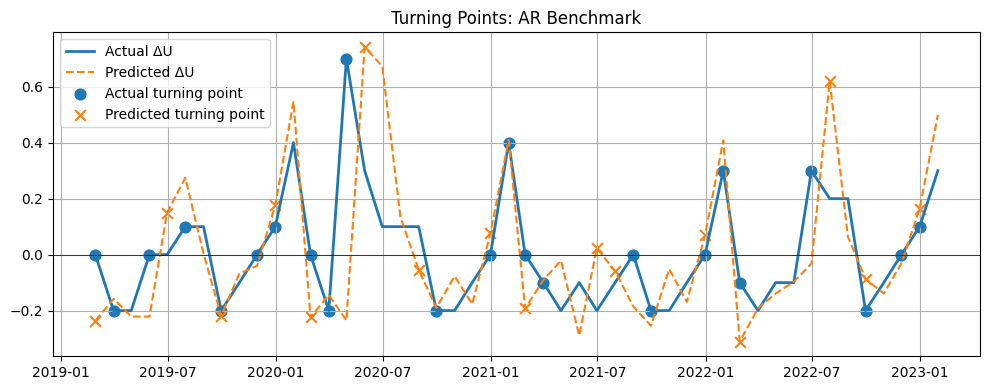

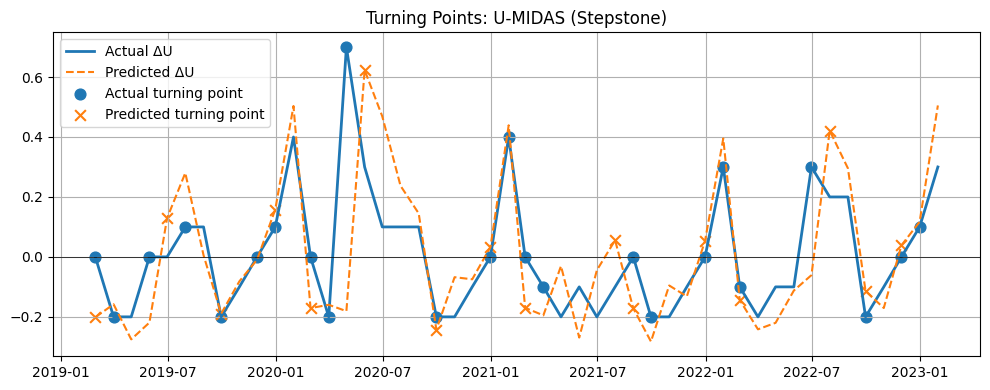

In [41]:
plot_turning_points(
    store["AR(dU,p=2)"]["pred"],
    store["AR(dU,p=2)"]["act"],
    title="Turning Points: AR Benchmark"
)

plot_turning_points(
    store["U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone]"]["pred"],
    store["U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone]"]["act"],
    title="Turning Points: U-MIDAS (Stepstone)"
)


Confusion-matrix and timeline diagnostics indicate that MIDAS specifications are more sensitive to changes in unemployment dynamics, leading to a higher detection rate of turning points. While this responsiveness comes at the cost of additional false alarms, the results suggest that high-frequency Google search data may be valuable as an early-warning signal rather than as a tool for improving point forecast accuracy.”